In [ ]:
import torch, torchvision
import os

# Google Drive baglantisi
from google.colab import drive
drive.mount('/content/drive')

# Detectron2 Kurulumu
!python -m pip install 'git+https://github.com/facebookresearch/detectron2.git' > /dev/null

# Roboflow
!pip install -q roboflow

print("Kurulum tamamlandı.")

Mounted at /content/drive
⏳ Detectron2 kuruluyor (1-2 dk sürebilir)...
  Running command git clone --filter=blob:none --quiet https://github.com/facebookresearch/detectron2.git /tmp/pip-req-build-ri009xmx
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 89.9/89.9 kB 9.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 66.8/66.8 kB 6.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 49.9/49.9 MB 56.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 84.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.2/4.2 MB 133.4 MB/s eta 0:00:00
Kurulum tamamlandı.


In [ ]:
from roboflow import Roboflow
from detectron2.data.datasets import register_coco_instances
from detectron2.data import MetadataCatalog, DatasetCatalog
import json
import os

from roboflow import Roboflow
rf = Roboflow(api_key="*********")
project = rf.workspace("khaled-hjb0q").project("tooth-instance-segmentation-vrbtu")
version = project.version(1)
dataset = version.download("coco")

folders = [d for d in os.listdir('/content') if os.path.isdir(d) and "Tooth" in d]
if not folders:
    raise FileNotFoundError("Veri seti klasörü bulunamadı.")
dataset_dir = os.path.join('/content', folders[0])
print(f"Veri Seti Klasörü: {dataset_dir}")

# Sınıf İsimlerini JSON'dan Çek
train_json_path = os.path.join(dataset_dir, "train/_annotations.coco.json")
with open(train_json_path, 'r') as f:
    data = json.load(f)

# ID sırasına göre isimleri al
categories = sorted(data['categories'], key=lambda x: x['id'])
class_names = [c['name'] for c in categories]
print(f"Tespit Edilecek Sınıflar: {class_names}")

# Detectron2'ye Kayıt
try:
    DatasetCatalog.remove("dis_train")
    DatasetCatalog.remove("dis_valid")
except:
    pass

register_coco_instances("dis_train", {}, train_json_path, f"{dataset_dir}/train")
register_coco_instances("dis_valid", {}, f"{dataset_dir}/valid/_annotations.coco.json", f"{dataset_dir}/valid")

# Metadata'yı güncelle
MetadataCatalog.get("dis_train").set(thing_classes=class_names)
MetadataCatalog.get("dis_valid").set(thing_classes=class_names)

print("Veri seti başarıyla sisteme tanıtıldı.")

loading Roboflow workspace...
loading Roboflow project...
Veri Seti Klasörü: /content/Tooth-instance-segmentation-1
Tespit Edilecek Sınıflar: ['teeth-segmentation', 'Caries', 'Crown', 'Crown - bridge', 'Filling', 'Implant', 'Periapical lesion', 'Post-screw', 'Root Canal Obturation']
Veri seti başarıyla sisteme tanıtıldı.


In [ ]:
# ~250 EPOCH HESAPLAMALI EĞİTİM
from detectron2.engine import DefaultTrainer
from detectron2.config import get_cfg
from detectron2 import model_zoo
import os

cfg = get_cfg()

# Model Mimarisi
cfg.merge_from_file(model_zoo.get_config_file("COCO-InstanceSegmentation/mask_rcnn_R_50_FPN_3x.yaml"))
cfg.MODEL.WEIGHTS = model_zoo.get_checkpoint_url("COCO-InstanceSegmentation/mask_rcnn_R_50_FPN_3x.yaml")

# Veri Seti
cfg.DATASETS.TRAIN = ("dis_train",)
cfg.DATASETS.TEST = ("dis_valid",)
cfg.DATALOADER.NUM_WORKERS = 2

# Epoch Hesaplaması
# Resim sayısını al
num_images = len(DatasetCatalog.get("dis_train"))
batch_size = 2 # Colab için güvenli sınır
target_epochs = 250

one_epoch_steps = num_images / batch_size
total_iterations = int(one_epoch_steps * target_epochs)

print(f" Analiz Raporu:")
print(f"   - Toplam Resim Sayısı: {num_images}")
print(f"   - 1 Epoch: {int(one_epoch_steps)} adım sürüyor.")
print(f"   - Hedef: {target_epochs} Epoch")
print(f"   - Toplam Eğitim Adımı (MAX_ITER): {total_iterations}")

# Hiperparametreler
cfg.SOLVER.IMS_PER_BATCH = batch_size
cfg.SOLVER.BASE_LR = 0.00025
cfg.SOLVER.MAX_ITER = total_iterations
cfg.SOLVER.STEPS = (int(total_iterations * 0.7), int(total_iterations * 0.9))

cfg.MODEL.ROI_HEADS.BATCH_SIZE_PER_IMAGE = 128
cfg.MODEL.ROI_HEADS.NUM_CLASSES = len(class_names)

# Çıktı Klasörü (Drive)
cfg.OUTPUT_DIR = "/content/drive/MyDrive/BitirmeProjesi_250Epoch"
os.makedirs(cfg.OUTPUT_DIR, exist_ok=True)

print(f"Eğitim Başlıyor. Sonuçlar: {cfg.OUTPUT_DIR}")
trainer = DefaultTrainer(cfg)
trainer.resume_or_load(resume=False)
trainer.train()

Category ids in annotations are not in [1, #categories]! We'll apply a mapping for you.



📊 Analiz Raporu:
   - Toplam Resim Sayısı: 5144
   - 1 Epoch: 2572 adım sürüyor.
   - Hedef: 250 Epoch
   - Toplam Eğitim Adımı (MAX_ITER): 643000
🚀 Eğitim Başlıyor... Sonuçlar şurada olacak: /content/drive/MyDrive/BitirmeProjesi_250Epoch
[12/10 18:30:29 d2.engine.defaults]: Model:
GeneralizedRCNN(
  (backbone): FPN(
    (fpn_lateral2): Conv2d(256, 256, kernel_size=(1, 1), stride=(1, 1))
    (fpn_output2): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (fpn_lateral3): Conv2d(512, 256, kernel_size=(1, 1), stride=(1, 1))
    (fpn_output3): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (fpn_lateral4): Conv2d(1024, 256, kernel_size=(1, 1), stride=(1, 1))
    (fpn_output4): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (fpn_lateral5): Conv2d(2048, 256, kernel_size=(1, 1), stride=(1, 1))
    (fpn_output5): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (top_block): LastLevelMaxPool()
    (bo

model_final_f10217.pkl: 178MB [00:00, 231MB/s]                           
roi_heads.box_predictor.bbox_pred.{bias, weight}
roi_heads.box_predictor.cls_score.{bias, weight}
roi_heads.mask_head.predictor.{bias, weight}


[12/10 18:30:32 d2.engine.train_loop]: Starting training from iteration 0


torch.meshgrid: in an upcoming release, it will be required to pass the indexing argument. (Triggered internally at /pytorch/aten/src/ATen/native/TensorShape.cpp:4317.)
W1210 18:30:35.204000 4307 torch/fx/_symbolic_trace.py:52] is_fx_tracing will return true for both fx.symbolic_trace and torch.export. Please use is_fx_tracing_symbolic_tracing() for specifically fx.symbolic_trace or torch.compiler.is_compiling() for specifically torch.export/compile.


Görüntülenen çıkış son 5000 satıra kısaltıldı.
[12/10 22:29:50 d2.utils.events]:  eta: 2 days, 9:50:58  iter: 41239  total_loss: 0.9369  loss_cls: 0.1546  loss_box_reg: 0.3455  loss_mask: 0.2006  loss_rpn_cls: 0.02232  loss_rpn_loc: 0.1896    time: 0.3475  last_time: 0.3146  data_time: 0.0041  last_data_time: 0.0039   lr: 0.00025  max_mem: 1937M
[12/10 22:29:57 d2.utils.events]:  eta: 2 days, 9:49:01  iter: 41259  total_loss: 1.014  loss_cls: 0.1593  loss_box_reg: 0.3595  loss_mask: 0.2291  loss_rpn_cls: 0.0299  loss_rpn_loc: 0.1781    time: 0.3475  last_time: 0.3896  data_time: 0.0044  last_data_time: 0.0042   lr: 0.00025  max_mem: 1937M
[12/10 22:30:04 d2.utils.events]:  eta: 2 days, 9:50:44  iter: 41279  total_loss: 1.038  loss_cls: 0.1831  loss_box_reg: 0.3607  loss_mask: 0.2183  loss_rpn_cls: 0.02364  loss_rpn_loc: 0.2054    time: 0.3475  last_time: 0.3938  data_time: 0.0043  last_data_time: 0.0043   lr: 0.00025  max_mem: 1937M
[12/10 22:30:11 d2.utils.events]:  eta: 2 days, 9:51:

KeyboardInterrupt: 

⏳ Drive bağlanıyor ve kütüphaneler kuruluyor...
Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
  Running command git clone --filter=blob:none --quiet https://github.com/facebookresearch/detectron2.git /tmp/pip-req-build-uuon5auv
📂 Veri seti bilgileri çekiliyor...
loading Roboflow workspace...
loading Roboflow project...
✅ Sınıflar Yüklendi: ['teeth-segmentation', 'Caries', 'Crown', 'Crown - bridge', 'Filling', 'Implant', 'Periapical lesion', 'Post-screw', 'Root Canal Obturation']
⚙️ Model ayarlanıyor...
🚀 Model başarıyla yüklendi! Resim yüklemeye hazır.

Lütfen test etmek istediğiniz röntgen fotoğrafını seçin...


Saving testdata.png to testdata (1).png

🔍 testdata (1).png analiz ediliyor...


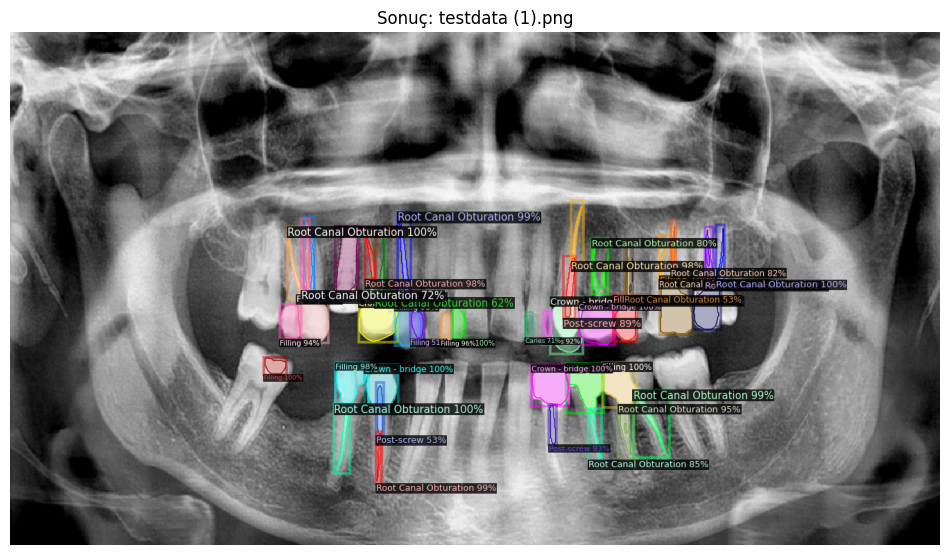

In [ ]:
import torch, torchvision
import os
import cv2
import json
import matplotlib.pyplot as plt
from google.colab import drive
from google.colab import files

# Kurulumlar
print("Drive bağlanıyor ve kütüphaneler kuruluyor...")
drive.mount('/content/drive')

# Detectron2 ve Roboflow tekrar kurulmalı
!python -m pip install 'git+https://github.com/facebookresearch/detectron2.git' > /dev/null
!pip install -q roboflow

from detectron2.utils.visualizer import Visualizer, ColorMode
from detectron2.engine import DefaultPredictor
from detectron2.config import get_cfg
from detectron2.data import MetadataCatalog, DatasetCatalog
from detectron2 import model_zoo
from roboflow import Roboflow

# Metadata hazırlığı
# Sınıf isimlerini öğrenmek için veri setini hızlıca tekrar çekiyoruz.
print("Veri seti bilgileri çekiliyor...")

rf = Roboflow(api_key="**********")
project = rf.workspace("khaled-hjb0q").project("tooth-instance-segmentation-vrbtu")
version = project.version(1)
dataset = version.download("coco")

# Klasör yolunu bul
folders = [d for d in os.listdir('/content') if os.path.isdir(d) and "Tooth" in d]
dataset_dir = os.path.join('/content', folders[0])
train_json_path = os.path.join(dataset_dir, "train/_annotations.coco.json")

# Sınıf isimlerini JSON'dan çek
with open(train_json_path, 'r') as f:
    data = json.load(f)
categories = sorted(data['categories'], key=lambda x: x['id'])
class_names = [c['name'] for c in categories]

# Metadata kataloğunu oluştur
try:
    DatasetCatalog.remove("test_set")
except:
    pass
# Geçici bir kayıt oluşturuyoruz
MetadataCatalog.get("test_set").set(thing_classes=class_names)
test_metadata = MetadataCatalog.get("test_set")

print(f"Sınıflar Yüklendi: {class_names}")

# Kayıtlı Model Yükleme
print("Model ayarlanıyor...")
cfg = get_cfg()
cfg.merge_from_file(model_zoo.get_config_file("COCO-InstanceSegmentation/mask_rcnn_R_50_FPN_3x.yaml"))

cfg.OUTPUT_DIR = "/content/drive/MyDrive/BitirmeProjesi_250Epoch"
cfg.MODEL.WEIGHTS = os.path.join(cfg.OUTPUT_DIR, "model_0139999.pth")

cfg.MODEL.ROI_HEADS.NUM_CLASSES = len(class_names)
cfg.MODEL.ROI_HEADS.SCORE_THRESH_TEST = 0.5  # %50 üzerindeki ihtimalleri göster
cfg.MODEL.DEVICE = "cuda" if torch.cuda.is_available() else "cpu"

# Tahminciyi oluştur
if not os.path.exists(cfg.MODEL.WEIGHTS):
    print(f"HATA: Model dosyası bulunamadı! Yolu kontrol edin: {cfg.MODEL.WEIGHTS}")
else:
    predictor = DefaultPredictor(cfg)
    print("Model başarıyla yüklendi!")

    # Resim yükleme ve test
    print("\nLütfen test etmek istediğiniz röntgen fotoğrafını seçin...")
    uploaded = files.upload()

    for filename in uploaded.keys():
        print(f"\n🔍 {filename} analiz ediliyor...")
        im = cv2.imread(filename)

        # Tahmin Yap
        outputs = predictor(im)

        # Çizim Yap
        v = Visualizer(im[:, :, ::-1],
                       metadata=test_metadata,
                       scale=1.2,
                       instance_mode=ColorMode.IMAGE_BW
        )
        out = v.draw_instance_predictions(outputs["instances"].to("cpu"))

        # Göster
        plt.figure(figsize=(12, 12))
        plt.imshow(out.get_image()[:, :, ::-1])
        plt.axis('off')
        plt.title(f"Sonuç: {filename}")
        plt.show()

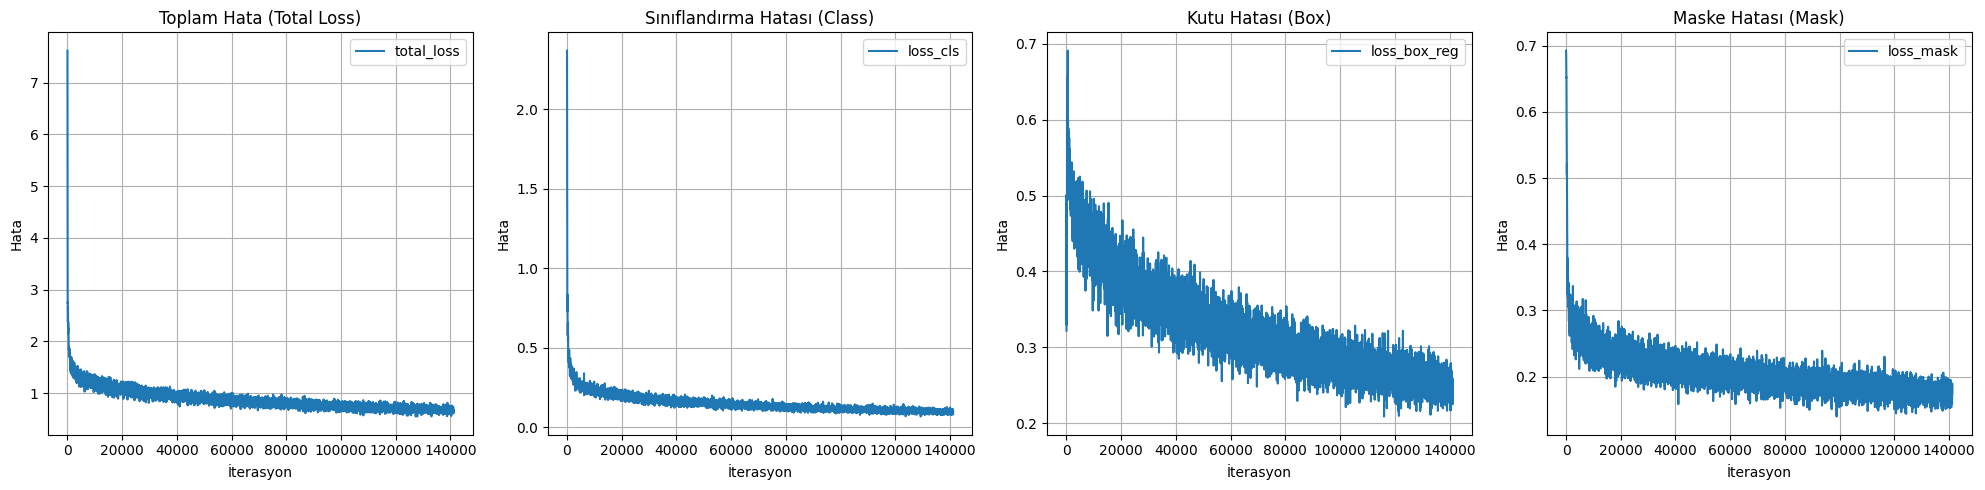

In [ ]:
import json
import matplotlib.pyplot as plt
import os

# Modelin klasör yolu
experiment_folder = "/content/drive/MyDrive/BitirmeProjesi_250Epoch"
json_file = os.path.join(experiment_folder, "metrics.json")

def load_json_arr(json_path):
    lines = []
    with open(json_path, 'r') as f:
        for line in f:
            lines.append(json.loads(line))
    return lines

if os.path.exists(json_file):
    experiment_metrics = load_json_arr(json_file)

    # Çizdirmek istediğimiz metrikler
    metrics_to_plot = ['total_loss', 'loss_cls', 'loss_box_reg', 'loss_mask']
    titles = ['Toplam Hata (Total Loss)', 'Sınıflandırma Hatası (Class)', 'Kutu Hatası (Box)', 'Maske Hatası (Mask)']

    plt.figure(figsize=(20, 5))

    for i, metric in enumerate(metrics_to_plot):
        # Sadece ilgili metriğin olduğu iterasyonları al
        iterations = [x['iteration'] for x in experiment_metrics if metric in x]
        values = [x[metric] for x in experiment_metrics if metric in x]

        plt.subplot(1, 4, i+1)
        plt.plot(iterations, values, label=metric)
        plt.title(titles[i])
        plt.xlabel('İterasyon')
        plt.ylabel('Hata')
        plt.grid(True)
        plt.legend()

    plt.tight_layout()
    plt.show()
else:
    print(f" Dosya bulunamadı: {json_file}")

✅ Analiz için yüklenen model: model_0139999.pth
[12/11 08:22:37 d2.checkpoint.detection_checkpoint]: [DetectionCheckpointer] Loading from /content/drive/MyDrive/BitirmeProjesi_250Epoch/model_0139999.pth ...
WARNING [12/11 08:22:37 d2.data.datasets.coco]: 
Category ids in annotations are not in [1, #categories]! We'll apply a mapping for you.

[12/11 08:22:37 d2.data.datasets.coco]: Loaded 729 images in COCO format from /content/Tooth-instance-segmentation-1/valid/_annotations.coco.json
📊 729 adet resim analiz ediliyor...


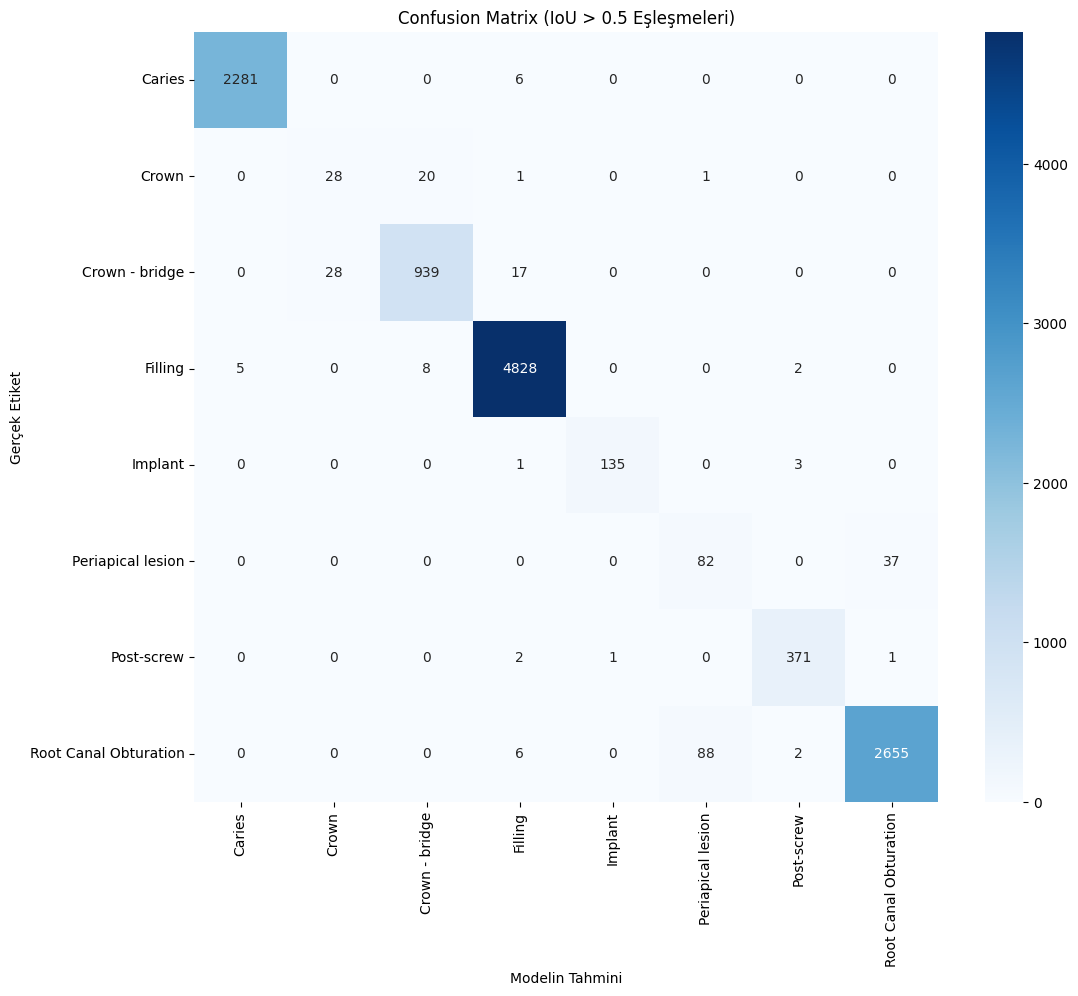

In [ ]:
from detectron2.engine import DefaultPredictor
from detectron2.config import get_cfg
from detectron2 import model_zoo
from detectron2.data import DatasetCatalog, MetadataCatalog
from detectron2.structures import BoxMode
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt
import cv2
import torch
import numpy as np
import os
import glob

# Modeli yükle
output_dir = "/content/drive/MyDrive/BitirmeProjesi_250Epoch"

# En son kaydedilen modeli bul
list_of_models = glob.glob(os.path.join(output_dir, "*.pth"))
if not list_of_models:
    print("Model dosyası bulunamadı! Eğitim klasörünü kontrol edin.")
    raise FileNotFoundError("Model yok.")

latest_model = max(list_of_models, key=os.path.getctime)
print(f" Analiz için yüklenen model: {os.path.basename(latest_model)}")

cfg = get_cfg()
cfg.merge_from_file(model_zoo.get_config_file("COCO-InstanceSegmentation/mask_rcnn_R_50_FPN_3x.yaml"))
cfg.MODEL.WEIGHTS = latest_model
cfg.MODEL.ROI_HEADS.SCORE_THRESH_TEST = 0.5

# Sınıf sayısını al
try:
    metadata = MetadataCatalog.get("dis_train")
    class_names = metadata.thing_classes
    cfg.MODEL.ROI_HEADS.NUM_CLASSES = len(class_names)
except:
    # Metadata yoksa manuel tanımla
    class_names = [f"Sinif_{i}" for i in range(80)]
    cfg.MODEL.ROI_HEADS.NUM_CLASSES = 80

predictor = DefaultPredictor(cfg)

# IoU hesaplama
def get_iou(boxA, boxB):
    xA = max(boxA[0], boxB[0])
    yA = max(boxA[1], boxB[1])
    xB = min(boxA[2], boxB[2])
    yB = min(boxA[3], boxB[3])
    interArea = max(0, xB - xA) * max(0, yB - yA)
    boxAArea = (boxA[2] - boxA[0]) * (boxA[3] - boxA[1])
    boxBArea = (boxB[2] - boxB[0]) * (boxB[3] - boxB[1])
    iou = interArea / float(boxAArea + boxBArea - interArea + 1e-6)
    return iou

# Analiz
y_true = []
y_pred = []
dataset_dicts = DatasetCatalog.get("dis_valid") # Validasyon seti

print(f" {len(dataset_dicts)} adet resim analiz ediliyor...")

for d in dataset_dicts:
    im = cv2.imread(d["file_name"])
    outputs = predictor(im)

    # Tahminler
    pred_boxes = outputs["instances"].pred_boxes.tensor.cpu().numpy()
    pred_classes = outputs["instances"].pred_classes.cpu().numpy()

    # Gerçekler (Annotations)
    gt_boxes = []
    gt_classes = []
    for ann in d["annotations"]:
        gt_boxes.append(ann["bbox"])
        gt_classes.append(ann["category_id"])

    # Eşleştirme (Matching)
    used_gt_indices = set()

    for i, p_box in enumerate(pred_boxes):
        best_iou = 0
        best_gt_idx = -1

        # Bu tahmin hangi gerçek kutuya benziyor?
        for j, g_box in enumerate(gt_boxes):
            # Detectron2 XYXY formatında, COCO XYWH olabilir. Dönüşüm gerekebilir.
            # Roboflow exportları genellikle XYXY gelir, direkt kıyaslayalım:
            iou = get_iou(p_box, g_box)
            # Eğer IoU çok düşük çıkarsa format farkı vardır, XYWH dönüşümü deneriz:
            if iou < 0.1:
                # XYWH -> XYXY dönüşümü denemesi
                g_box_xyxy = [g_box[0], g_box[1], g_box[0]+g_box[2], g_box[1]+g_box[3]]
                iou = get_iou(p_box, g_box_xyxy)

            if iou > best_iou:
                best_iou = iou
                best_gt_idx = j

        # Eğer %50'den fazla örtüşüyorsa eşleştir
        if best_iou > 0.5:
            y_pred.append(class_names[pred_classes[i]])
            y_true.append(class_names[gt_classes[best_gt_idx]])
            used_gt_indices.add(best_gt_idx)

# Grafik çiz
if len(y_true) > 0:
    unique_classes = sorted(list(set(y_true + y_pred)))
    cm = confusion_matrix(y_true, y_pred, labels=unique_classes)

    plt.figure(figsize=(12, 10))
    sns.heatmap(cm, annot=True, fmt='d', xticklabels=unique_classes, yticklabels=unique_classes, cmap='Blues')
    plt.xlabel('Modelin Tahmini')
    plt.ylabel('Gerçek Etiket')
    plt.title('Confusion Matrix (IoU > 0.5 Eşleşmeleri)')
    plt.show()
else:
    print("Yeterli eşleşme bulunamadı! Model henüz hiç bir doğru kutu çizemiyor olabilir.")

In [ ]:
from detectron2.evaluation import COCOEvaluator, inference_on_dataset
from detectron2.data import build_detection_test_loader
from detectron2.config import get_cfg
from detectron2 import model_zoo
from detectron2.modeling import build_model
from detectron2.checkpoint import DetectionCheckpointer
import os

output_dir = "/content/drive/MyDrive/BitirmeProjesi_250Epoch" #

cfg = get_cfg()
cfg.merge_from_file(model_zoo.get_config_file("COCO-InstanceSegmentation/mask_rcnn_R_50_FPN_3x.yaml"))
cfg.MODEL.ROI_HEADS.SCORE_THRESH_TEST = 0.5

# En son modeli bul
import glob
list_of_models = glob.glob(os.path.join(output_dir, "*.pth"))
if not list_of_models:
    raise FileNotFoundError("Model dosyası bulunamadı!")
latest_model = max(list_of_models, key=os.path.getctime)
print(f"İncelenen Model: {os.path.basename(latest_model)}")

cfg.MODEL.WEIGHTS = latest_model
# Sınıf sayısını veri setinden al, yoksa varsayılan yap
from detectron2.data import MetadataCatalog
try:
    cfg.MODEL.ROI_HEADS.NUM_CLASSES = len(MetadataCatalog.get("dis_train").thing_classes)
except:
    cfg.MODEL.ROI_HEADS.NUM_CLASSES = 80

# --- 2. MODELİ İNŞA ET ---
# Evaluator, 'Predictor' değil ham 'Model' ister.
model = build_model(cfg)
DetectionCheckpointer(model).load(cfg.MODEL.WEIGHTS)
model.eval() # Modeli test moduna al

# --- 3. DEĞERLENDİRME (EVALUATION) ---
print("\n mAP Değerleri Hesaplanıyor... (Bu işlem biraz zaman alabilir)")

# Evaluator'ı hazırla
evaluator = COCOEvaluator("dis_valid", cfg, False, output_dir=output_dir)
val_loader = build_detection_test_loader(cfg, "dis_valid")

# Hesapla
results = inference_on_dataset(model, val_loader, evaluator)

# --- 4. SONUÇLARI YAZDIR ---
print("\n" + "="*40)
print(" SONUÇ RAPORU")
print("="*40)
# mAP değerlerini çekelim (Segm = Segmentation, Bbox = Bounding Box)
print(f"Segm (Maske) mAP50: %{results['segm']['AP50']:.2f}")
print(f"Segm (Maske) mAP50-95: %{results['segm']['AP']:.2f}")
print("-" * 20)
print(f"Box (Kutu) mAP50:  %{results['bbox']['AP50']:.2f}")
print(f"Box (Kutu) mAP50-95:  %{results['bbox']['AP']:.2f}")
print("="*40)

✅ İncelenen Model: model_0139999.pth
[12/11 08:24:46 d2.checkpoint.detection_checkpoint]: [DetectionCheckpointer] Loading from /content/drive/MyDrive/BitirmeProjesi_250Epoch/model_0139999.pth ...

📊 mAP Değerleri Hesaplanıyor... (Bu işlem biraz zaman alabilir)
WARNING [12/11 08:24:46 d2.evaluation.coco_evaluation]: COCO Evaluator instantiated using config, this is deprecated behavior. Please pass in explicit arguments instead.
WARNING [12/11 08:24:47 d2.data.datasets.coco]: 
Category ids in annotations are not in [1, #categories]! We'll apply a mapping for you.

[12/11 08:24:47 d2.data.datasets.coco]: Loaded 729 images in COCO format from /content/Tooth-instance-segmentation-1/valid/_annotations.coco.json
[12/11 08:24:47 d2.data.build]: Distribution of instances among all 9 categories:
|   category    | #instances   |  category  | #instances   |   category    | #instances   |
|:-------------:|:-------------|:----------:|:-------------|:-------------:|:-------------|
| teeth-segme.. | 0